In [6]:
import rastereasy

# Re projection

In [2]:
name_im = './data/demo/sentinel.tif'
image=rastereasy.open(name_im)
image.info()

- Size of the image:
   - Rows (height): 1000
   - Cols (width): 1000
   - Bands: 12
- Spatial resolution: 10.0  meters / degree (depending on projection system)
- Central point latitude - longitude coordinates: (7.04099599, 38.39058840)
- Driver: GTiff
- Data type: int16
- Projection system: EPSG:32637
- Nodata: -32768.0

- Given names for spectral bands: 
   {'1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12}




In [3]:
help(image.reproject)


Help on method reproject in module rastereasy:

reproject(projection='EPSG:3857', inplace=False, dest_name=None) method of rastereasy.Geoimage instance
    Reproject the image to a different coordinate reference system (CRS).

    This method transforms the image to a new projection system, which
    changes how the image's coordinates are interpreted. This can be useful for
    aligning data from different sources or preparing data for specific analyses.

    Parameters
    ----------
    projection : str, optional
        The target projection as an EPSG code or PROJ string.
        Examples:

        - "EPSG:4326": WGS84 geographic (lat/lon)

        - "EPSG:3857": Web Mercator (used by web maps)

        - "EPSG:32619": UTM Zone 19N
        Default is "EPSG:3857" (Web Mercator).

    inplace : bool, default False
        If False, return a copy. Otherwise, do reprojection in place and return None.

    dest_name : str, optional
        Path to save the reprojected image. If None, t

Two options

- Return a reprojected image (function `reproject`)
- Directly reproject the original image (function `reproject` with `inplace=True` option)

### 1) Return a reprojected image

----Original image--
- Size of the image:
   - Rows (height): 1000
   - Cols (width): 1000
   - Bands: 12
- Spatial resolution: 10.0  meters / degree (depending on projection system)
- Central point latitude - longitude coordinates: (7.04099599, 38.39058840)
- Driver: GTiff
- Data type: int16
- Projection system: EPSG:32637
- Nodata: -32768.0

- Given names for spectral bands: 
   {'CO': 1, 'B': 2, 'G': 3, 'R': 4, 'RE1': 5, 'RE2': 6, 'RE3': 7, 'NIR': 8, 'WA': 9, 'SWIR1': 10, 'SWIR2': 11, 'SWIR3': 12}




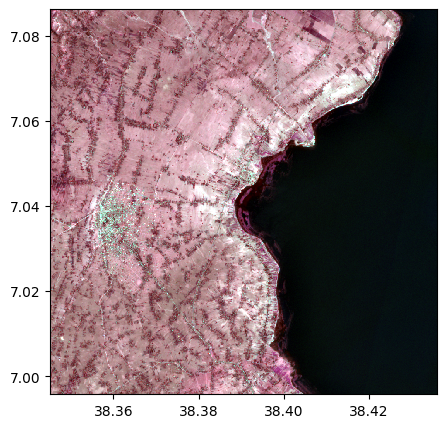

----Re projected image--
- Size of the image:
   - Rows (height): 1100
   - Cols (width): 1100
   - Bands: 12
- Spatial resolution: 13.086847568491946  meters / degree (depending on projection system)
- Central point latitude - longitude coordinates: (7.04105390, 38.39059931)
- Driver: GTiff
- Data type: int16
- Projection system: EPSG:27700
- Nodata: -32768.0

- Given names for spectral bands: 
   {'CO': 1, 'B': 2, 'G': 3, 'R': 4, 'RE1': 5, 'RE2': 6, 'RE3': 7, 'NIR': 8, 'WA': 9, 'SWIR1': 10, 'SWIR2': 11, 'SWIR3': 12}




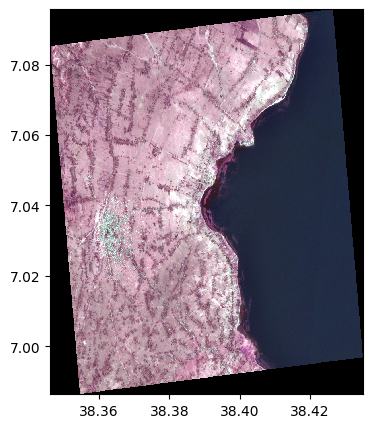

In [4]:
names = {"CO" : 1,"B": 2,"G":3,"R":4,"RE1":5,"RE2":6,"RE3":7,"NIR":8,"WA":9,"SWIR1":10,"SWIR2":11,"SWIR3":12}
image=rastereasy.open(name_im, names=names)
print('----Original image--')
image.info()
image.colorcomp(['RE1','B','G'])
# dest_name : to save the image
image_reprojected=image.reproject('EPSG:27700', dest_name='./data/results/save/reprojection.tif')
print('----Re projected image--')
image_reprojected.info()
image_reprojected.colorcomp(['RE1','B','G'])


### 2) Directly reproject to the image

----Original image--
- Size of the image:
   - Rows (height): 1000
   - Cols (width): 1000
   - Bands: 12
- Spatial resolution: 10.0  meters / degree (depending on projection system)
- Central point latitude - longitude coordinates: (7.04099599, 38.39058840)
- Driver: GTiff
- Data type: int16
- Projection system: EPSG:32637
- Nodata: -32768.0

- Given names for spectral bands: 
   {'1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12}




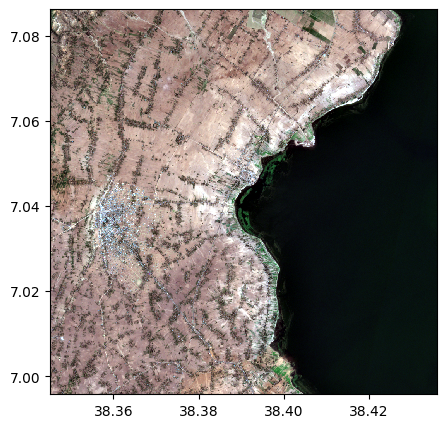

----Re projected image--
- Size of the image:
   - Rows (height): 1100
   - Cols (width): 1100
   - Bands: 12
- Spatial resolution: 13.086847568491946  meters / degree (depending on projection system)
- Central point latitude - longitude coordinates: (7.04105390, 38.39059931)
- Driver: GTiff
- Data type: int16
- Projection system: EPSG:27700
- Nodata: -32768.0

- Given names for spectral bands: 
   {'1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12}




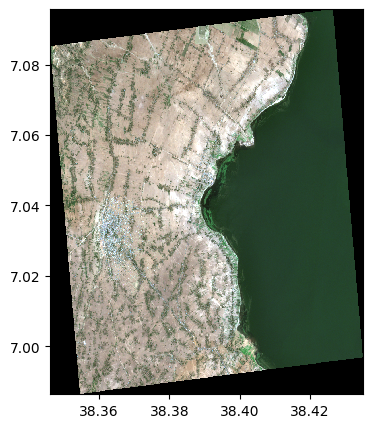

In [5]:
image=rastereasy.open(name_im)
print('----Original image--')
image.info()
image.colorcomp([4,3,2])
print('----Re projected image--')
image.reproject('EPSG:27700', inplace=True)
image.info()
image.colorcomp([4,3,2])
